In [4]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Optional: nicer default plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
df = pd.read_csv("ford.csv")
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
df.shape

(17966, 9)

### EDA

<Axes: xlabel='price', ylabel='Count'>

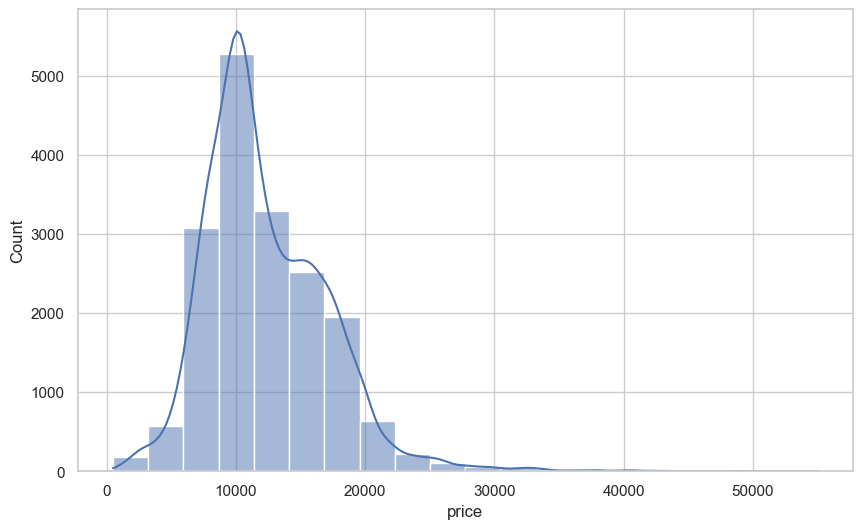

In [8]:
sns.histplot(df['price'] , bins = 20 , kde = True)

<Axes: >

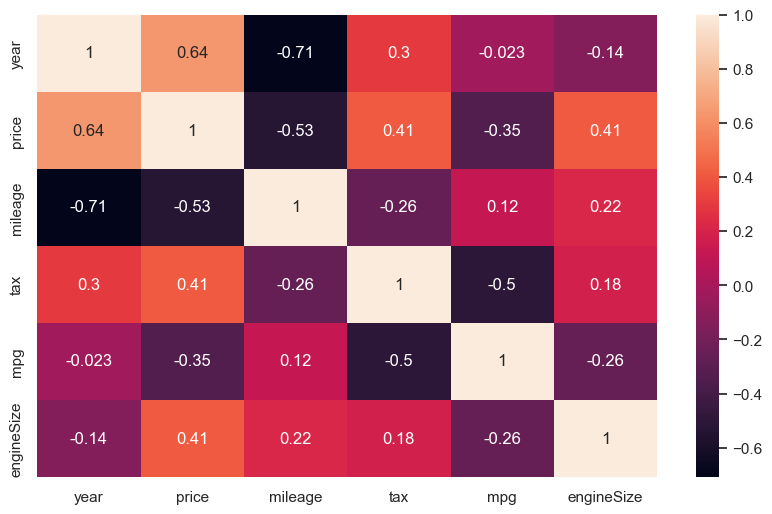

In [9]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

<Axes: xlabel='transmission', ylabel='price'>

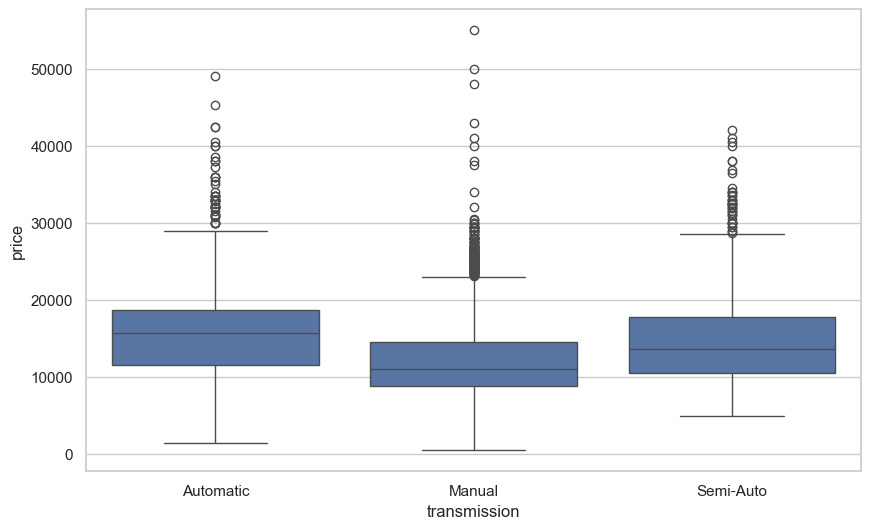

In [10]:
sns.boxplot(data = df, x = 'transmission',y = 'price')

In [11]:
X = df.drop(columns = ['price'],axis = 1)
y = df['price']

In [12]:
X_one_encode = pd.get_dummies(X,columns = ['model','transmission','fuelType'],drop_first = True)
X_one_encode = X_one_encode.astype(int)
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [13]:
from sklearn.preprocessing import LabelEncoder

columns = ['model', 'transmission', 'fuelType']

Xlable = X.copy()  # make a safe copy

for col in columns:
    le = LabelEncoder()
    Xlable[col] = le.fit_transform(Xlable[col].astype(str))  # Convert to string in case of nulls

In [14]:
Xlable

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


#### Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X_one_encode[numerical_cols] = scaler.fit_transform(X_one_encode[numerical_cols])

In [16]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [17]:
Xlable[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scaler.fit_transform(Xlable[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

## Model Training

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.33, random_state=42)

In [20]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)
y_pred

array([ 6888.75487917,  9328.62297666,  9420.53085767, ...,
       19099.96373064,  4948.44438264, 10424.59544226], shape=(5929,))

In [22]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [23]:
r2 = r2_score(y_test,y_pred)
r2

0.8396626991294074

In [24]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.8387377808685319


In [25]:
X_train, X_test, y_train, y_test = train_test_split(Xlable, y, test_size=0.33, random_state=42)
model2 = LinearRegression()
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test)
r2 = r2_score(y_test,y_pred)
r2

0.7310215557391141

In [26]:
X_test

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
17610,-0.460699,-1.398088,0.041351,-0.080611,0.688777,-1.827578,0.769650,-0.811386
7076,-0.460699,0.065128,0.041351,0.290547,0.688777,0.591358,0.769650,-0.811386
1713,-0.211477,-0.910349,0.041351,1.170551,-1.454098,-1.505053,0.927668,0.576362
1611,-1.706810,-1.885826,0.041351,1.010368,0.688777,-1.343791,-0.247593,-0.811386
16830,1.782301,-3.836780,0.041351,2.857374,-1.454098,1.397670,-0.909294,1.038944
...,...,...,...,...,...,...,...,...
6015,-0.211477,1.040605,0.041351,-0.908538,-1.454098,0.510727,1.253580,1.501527
10301,-0.460699,-0.422611,2.752735,-0.746198,0.688777,-1.827578,-0.020442,-0.811386
15006,1.533079,1.040605,-2.670032,-0.812089,0.688777,0.510727,-2.845018,0.345070
5396,-1.706810,-1.885826,2.752735,1.645552,0.688777,0.752620,-1.363597,0.576362


In [27]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [30]:
linreg_results = []

def evaluate_linear_regression(X_train, y_train, X_test, y_test):
    start = time.time()
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    mae = mean_absolute_error(y_test, y_pred)
    # rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    linreg_results.append({
        'Model': 'Linear Regression',
        'R2': round(r2, 4),
        'MAE': round(mae, 2),
        # 'RMSE': round(rmse, 2),
        'Train+Predict Time (s)': round(elapsed, 2)
    })

    print(f"Linear Regression done in {elapsed:.2f} sec | R2: {r2:.4f} | MAE: {mae:.2f}" ) 
          # | RMSE: {rmse:.2f}")
    return model, y_pred

In [31]:
# Run only Linear Regression
lin_reg_model, y_pred_linreg = evaluate_linear_regression(
    X_train, y_train, X_test, y_test
)

Linear Regression done in 0.00 sec | R2: 0.7310 | MAE: 1764.68


In [32]:
pd.DataFrame(linreg_results)

,Model,R2,MAE,Train+Predict Time (s)
0,Linear Regression,0.731,1764.68,0.0


In [33]:
import joblib
joblib.dump(lin_reg_model, 'linear_regression_ford.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']